<a href="https://colab.research.google.com/github/MamidiPravallikaReddy/DL_LAB/blob/main/DL_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

--2026-04-14 07:38:51--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  5.98MB/s    in 27s     

2026-04-14 07:39:18 (6.53 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2026-04-14 07:39:18--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  6.62MB/s    in 8.9s    

2026-04-14 07:39:27 (6.88 MB/s) - ‘test_32x32.mat’ saved [64275384/64

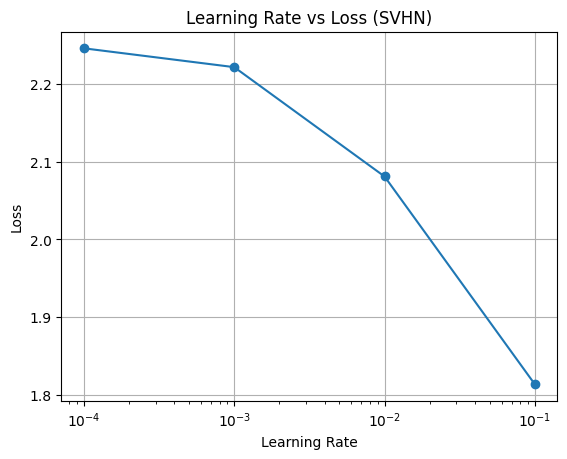


Learning Rate vs Loss:
LR: 0.0001 → Loss: 2.2462
LR: 0.001 → Loss: 2.2219
LR: 0.01 → Loss: 2.0811
LR: 0.1 → Loss: 1.8135
LR: 1.0 → Loss: nan


In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train = scipy.io.loadmat('train_32x32.mat')
test = scipy.io.loadmat('test_32x32.mat')

X_train = np.transpose(train['X'], (3,0,1,2))[:20000]
Y_train = train['y'][:20000]

X_test = np.transpose(test['X'], (3,0,1,2))[:5000]
Y_test = test['y'][:5000]

Y_train[Y_train == 10] = 0
Y_test[Y_test == 10] = 0

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

loss_results = []

for lr in learning_rates:
    print(f"\nTraining with Learning Rate = {lr}")

    model = Sequential([
        Input(shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    final_loss = history.history['loss'][-1]
    loss_results.append(final_loss)

    print(f"Final Loss: {final_loss:.4f}")

plt.figure()
plt.plot(learning_rates, loss_results, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss (SVHN)")
plt.grid()
plt.show()

print("\nLearning Rate vs Loss:")
for lr, loss in zip(learning_rates, loss_results):
    print(f"LR: {lr} → Loss: {loss:.4f}")

Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

--2026-04-14 07:54:27--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat.1’

train_32x32.mat.1   100%[===================>] 173.61M  4.30MB/s    in 50s     

2026-04-14 07:55:18 (3.46 MB/s) - ‘train_32x32.mat.1’ saved [182040794/182040794]

--2026-04-14 07:55:18--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat.1’

test_32x32.mat.1    100%[===================>]  61.30M  11.7MB/s    in 8.2s    

2026-04-14 07:55:26 (7.45 MB/s) - ‘test_32x32.mat.1’ saved [642

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1862 - loss: 2.2439 - val_accuracy: 0.1985 - val_loss: 2.2283
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.2081 - loss: 2.2131 - val_accuracy: 0.1860 - val_loss: 2.2063
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2166 - loss: 2.1886 - val_accuracy: 0.1990 - val_loss: 2.1811
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2358 - loss: 2.1608 - val_accuracy: 0.2042 - val_loss: 2.1575
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2514 - loss: 2.1271 - val_accuracy: 0.2498 - val_loss: 2.1381
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.2731 - loss: 2.0879 - val_accuracy: 0.2623 - val_loss: 2.0733
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2996 - loss: 2.0412 - val_accuracy: 0.2948 - val_loss: 2.0273
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3217 - loss: 1.9875 - val_accu

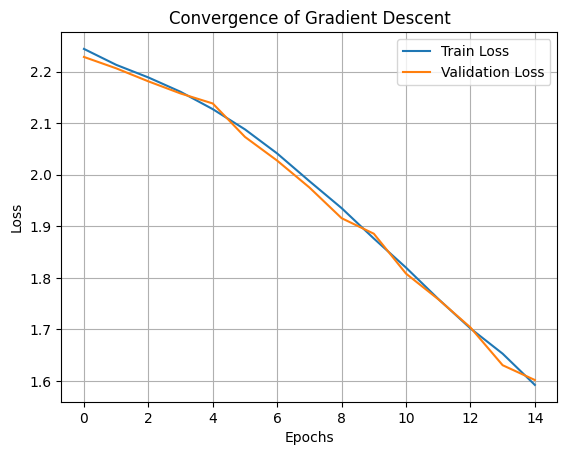

In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train = scipy.io.loadmat('train_32x32.mat')
test = scipy.io.loadmat('test_32x32.mat')

X_train = np.transpose(train['X'], (3,0,1,2))[:20000]
Y_train = train['y'][:20000]

X_test = np.transpose(test['X'], (3,0,1,2))[:5000]
Y_test = test['y'][:5000]

Y_train[Y_train == 10] = 0
Y_test[Y_test == 10] = 0

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

model = Sequential([
    Input(shape=(3072,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", test_acc)

plt.figure()

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.grid()

plt.show()

Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)

perceptron = Perceptron()

perceptron.fit(X_train, y_train)

y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

--2026-04-14 07:58:22--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat.2’

train_32x32.mat.2   100%[===================>] 173.61M  2.14MB/s    in 34s     

2026-04-14 07:58:56 (5.14 MB/s) - ‘train_32x32.mat.2’ saved [182040794/182040794]

--2026-04-14 07:58:56--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat.2’

test_32x32.mat.2    100%[===================>]  61.30M  12.0MB/s    in 8.6s    

2026-04-14 07:59:04 (7.10 MB/s) - ‘test_32x32.mat.2’ saved [642

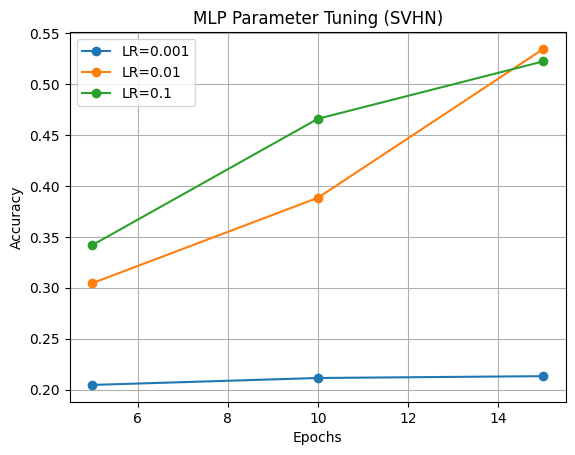

In [3]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam

!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train = scipy.io.loadmat('train_32x32.mat')
test = scipy.io.loadmat('test_32x32.mat')

X_train = np.transpose(train['X'], (3,0,1,2))[:20000]
Y_train = train['y'][:20000]

X_test = np.transpose(test['X'], (3,0,1,2))[:5000]
Y_test = test['y'][:5000]

Y_train[Y_train == 10] = 0
Y_test[Y_test == 10] = 0

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

def build_model():
    model = Sequential([
        Input(shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

learning_rates = [0.001, 0.01, 0.1]
epochs_list = [5, 10, 15]

results = []

for lr in learning_rates:
    for ep in epochs_list:

        print(f"\nTraining → LR={lr}, Epochs={ep}")

        model = build_model()

        model.compile(
            optimizer=SGD(learning_rate=lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, Y_train,
            epochs=ep,
            batch_size=128,
            verbose=0
        )

        loss, acc = model.evaluate(X_test, Y_test, verbose=0)

        results.append((lr, ep, acc))

        print(f"Accuracy: {acc:.4f}")

print("\nFinal Results:")
for lr, ep, acc in results:
    print(f"LR={lr}, Epochs={ep} → Accuracy={acc:.4f}")

plt.figure()

for lr in learning_rates:
    accs = [acc for (lr2, ep, acc) in results if lr2 == lr]
    plt.plot(epochs_list, accs, marker='o', label=f"LR={lr}")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("MLP Parameter Tuning (SVHN)")
plt.legend()
plt.grid()

plt.show()

Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).

Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.54125506
Iteration 2, loss = 0.26261541
Iteration 3, loss = 0.21334693
Iteration 4, loss = 0.18041799
Iteration 5, loss = 0.15521071
Iteration 6, loss = 0.13713162
Iteration 7, loss = 0.12167082
Iteration 8, loss = 0.10957409
Iteration 9, loss = 0.09910434
Iteration 10, loss = 0.09005121
Iteration 11, loss = 0.08238981
Iteration 12, loss = 0.07590413
Iteration 13, loss = 0.06990400
Iteration 14, loss = 0.06552830
Iteration 15, loss = 0.06068202
Iteration 16, loss = 0.05696692
Iteration 17, loss = 0.05327114
Iteration 18, loss = 0.04979526
Iteration 19, loss = 0.04618848
Iteration 20, loss = 0.04420099
Iteration 21, loss = 0.04145133
Iteration 22, loss = 0.03863193
Iteration 23, loss = 0.03670778
Iteration 24, loss = 0.03395817
Iteration 25, loss = 0.03256089
Iteration 26, loss = 0.03003133
Iteration 27, loss = 0.02852477
Iteration 28, loss = 0.02670121
Iteration 29, loss = 0.02499706
Iteration 30, loss = 0.02

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9996666666666667
Testing set score: 0.974
Predicted value: 6
Actual value: 6


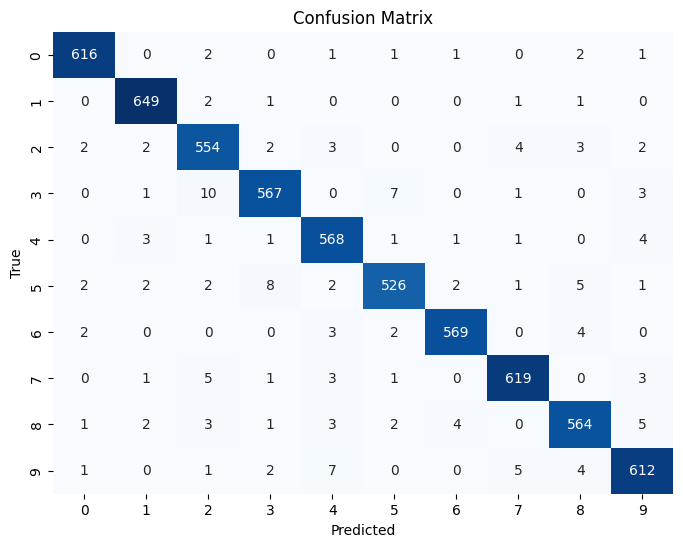

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)

prediction = mlp.predict(test_digit)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))